# Multi-Model Switching with Contact


In [1]:
from pathlib import Path
import sys
_repo = Path.cwd()
while _repo != _repo.parent and not (_repo / "pyproject.toml").exists():
    _repo = _repo.parent
sys.path.insert(0, str(_repo))

In [2]:
import numpy as np

from pathlib import Path
from matplotlib.ticker import ScalarFormatter
from thesis.notebooks.plot_setup import METRIC_COLORS, REFERENCE_COLOR, STEP_SIZE_COLORS

from thesis.notebooks.plot_setup import set_professional_style, FULL_WIDTH
plt = set_professional_style(latex=True)

from demos.ControlledPendulum.src.master_pendulum import MasterPendulum
import demos.ControlledPendulum.src.master_pendulum.components.fem.pendulum_config as config
from syssimx import FMUComponent, System, SystemGraphVisualizer, Connection, EventConnection

## Discover FMUs

In [3]:
PLATFORM = sys.platform
demo_dir_path = _repo / "demos" / "ControlledPendulum"
package_path = Path(demo_dir_path / "src/modelica/ControlledPendulum")
fmu_output_dir = Path(demo_dir_path / f"artifacts/fmus/{PLATFORM}")

fmu_paths = {}
for subdir in fmu_output_dir.iterdir():
    if subdir.is_dir():
        fmu_paths[subdir.name] = {}
        for fmu_file in subdir.glob("*.fmu"):
            fmu_paths[subdir.name][fmu_file.stem] = fmu_file
    else:
        fmu_paths[subdir.stem] = subdir


## Modelica Reference Simulation

In [4]:
from OMPython import ModelicaSystem

reference = ModelicaSystem(fileName=str(package_path / "package.mo"),
                           modelName="ControlledPendulum.Examples.Contact.RigidContact")
reference.setParameters({'useReset':'true'})
reference.buildModel()
reference.simulate()
ref_sol_names = ('time', 'theta', 'theta_ref', 'theta_meas', 'pid.I_out', 'pendulum.contact')
ref_sol_reset = {name: reference.getSolutions(name).flatten() for name in ref_sol_names}

[OMC log for 'sendExpression(buildModel(ControlledPendulum.Examples.Contact.RigidContact, variableFilter=".*"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").
[OMC log for 'sendExpression(buildModel(ControlledPendulum.Examples.Contact.RigidContact, variableFilter=".*"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").


## Instantiate FMU Components

In [5]:
def print_parameteres(component: FMUComponent):
    print(f"Parameters of {component.name}:")
    for name, param in component.parameters.items():
        if '.' not in name and param is not None:
            print(f"  - {name}: {param}")

## Components

In [6]:
setpoint = FMUComponent(name="Setpoint",
                         fmu_path=fmu_paths['Trajectories']["SetPoint"],
                         group="Reference")

class PIDController(FMUComponent):
    def __init__(self, name):
        fmu_path = fmu_paths['Controllers']['PIDControllerReset_euler']
        super().__init__(name=name, fmu_path=fmu_path, group="Controller")
        self.use_reset = False  # Flag to control whether to apply reset on event
    
    def _handle_events_internal(self, event_names, t):
        if "wall_hit" not in event_names:
            return
        self.set_inputs({"resetI": True})
        self.do_step(t, 0)  # Perform a step to apply the resetI input
        self.set_inputs({"resetI": False})

pid = PIDController(name="PID")

drive = FMUComponent(name="Drive",
                     fmu_path=fmu_paths['Actuators']["DriveDynamic"],
                     group="Actuator")

sim_params = config.SimulationParameters()
sim_params.tau = 0.001
sim_params.t_end = 0.4
sim_params.with_contact = True
sim_params.use_gravity = True

anim_params = config.AnimationParameters()
anim_params.animate = False

fem_parameters = {
    'sim_params': sim_params,
    'anim_params': anim_params,
}

pendulum = MasterPendulum(name="MasterPendulum", initial_mode="FMU")
pendulum.record_switch_state = True
pendulum.set_parameters(**{"FEM": fem_parameters})
pendulum.initialize(t0=0.0)
pendulum._allow_mode_switching = True
pendulum.hysteresis.dwell_time = 0.01

def wall_contact_indicator(comp: MasterPendulum) -> float:
    theta = comp.get_outputs()["theta"]
    theta_wall = 0.0
    return theta - theta_wall

pendulum.add_event_indicator("wall_hit", func=wall_contact_indicator, direction=-1)

angle_sensor = FMUComponent(name="Angle Sensor",
                             fmu_path=fmu_paths['Sensors']['AngleSensor'],
                             group="Sensors")

angle_decoder = FMUComponent(name="Angle Decoder",
                             fmu_path=fmu_paths['Sensors']['AngleDecoder'],
                             group="Signal Processing")

## Connections

In [7]:
c1 = Connection(
    src_comp=setpoint.name,
    src_port=setpoint.output_specs["theta_ref"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["theta_ref"].name,
)

c21 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["theta"].name,
    dst_comp=angle_sensor.name,
    dst_port=angle_sensor.input_specs["theta"].name,
)

c22 = Connection(
    src_comp=angle_sensor.name,
    src_port=angle_sensor.output_specs["v_out"].name,
    dst_comp=angle_decoder.name,
    dst_port=angle_decoder.input_specs["v_in"].name,
)

c23 = Connection(
    src_comp=angle_decoder.name,
    src_port=angle_decoder.output_specs["theta"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["theta_meas"].name,
)

c3 = Connection(
    src_comp=pid.name,
    src_port=pid.output_specs["u"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["u_control"].name,
)

c4 = Connection(
    src_comp=drive.name,
    src_port=drive.output_specs["torque"].name,
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs["tau"].name,
)

c5 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["omega"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["omega"].name,
)

event_connection_1 = EventConnection(
    src_comp=pendulum.name,
    src_port="wall_hit",
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs["omega_invert"].name,
)

event_connection_2 = EventConnection(
    src_comp=pendulum.name,
    src_port="wall_hit",
    dst_comp=pid.name,
    dst_port=pid.input_specs["resetI"].name,
)

connections = [c1, c21, c22, c23, c3, c4, c5]
components  = [setpoint, pid, drive, pendulum, angle_decoder, angle_sensor]

system = System(name="Pendulum System with Master Pendulum")

for comp in components:
    system.add_component(comp)

for conn in connections:
    system.add_connection(conn)

system.add_event_connection(event_connection_1)
system.add_event_connection(event_connection_2)

system.initialize(t0=0.0)

In [8]:
system.algorithm.record_internal_steps = False
system.algorithm.event_dedup_tol = 5e-4
system.algorithm.tol_time = 1e-5
system.algorithm.tol_value = 5e-5

## Run Simulation

In [9]:
t = 0.0
dt = sim_params.tau
t_end = sim_params.t_end

system.run(t, t_end, dt)

[FEM_Pendulum] Event 'wall_hit' at t=0.172438s.
[FEM_Pendulum] Event 'wall_hit' at t=0.211338s.
[FEM_Pendulum] Event 'wall_hit' at t=0.250444s.
[FEM_Pendulum] Event 'wall_hit' at t=0.289369s.
[FEM_Pendulum] Event 'wall_hit' at t=0.328069s.


In [10]:
# system_res_file = Path.cwd() / "demos/ControlledPendulum/artifacts/results/master_pendulum_system.csv"
# system_res_file.parent.mkdir(parents=True, exist_ok=True)
# system.history.save_csv(filepath=system_res_file)

## Collect Results

In [11]:
history = system.get_history()
fem_hist = pendulum.fem.get_history()
fmu_hist = pendulum.fmu.get_history()
opensim_hist = pendulum.opensim.get_history()

ref_history = history["Setpoint"]
setpoint_time, data = ref_history
theta_ref = data["theta_ref"]

t_fem = fem_hist['theta']['time']
theta_fem = fem_hist['theta']['values']
t_fmu = fmu_hist['theta']['time']
theta_fmu = fmu_hist['theta']['values']
t_opensim = opensim_hist['theta']['time']
theta_opensim = opensim_hist['theta']['values']

t_pid = history["PID"][0]
i_out = history["PID"][1]['I_out']

event_history = history['Events']
event_times_dense = event_history[('MasterPendulum', 'wall_hit')]
event_times_float = [dt.t for dt in event_times_dense]#[:-1]
event_indices = np.where(ref_sol_reset['pendulum.contact'] > 0)[0]
event_times_ref_indices = np.where(ref_sol_reset['time'][event_indices] <= t_end)[0]
event_times_ref = ref_sol_reset['time'][event_indices][event_times_ref_indices][::2]

diff_event_times = np.array(event_times_float) - np.array(event_times_ref)

In [12]:
import numpy as np
import pandas as pd

def trajectory_error_metrics(t, y, t_ref, y_ref, *, t_min=None, t_max=None):
    """Compute sampled trajectory errors against an interpolated reference."""
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    t_ref = np.asarray(t_ref, dtype=float)
    y_ref = np.asarray(y_ref, dtype=float)

    mask = np.ones_like(t, dtype=bool)
    if t_min is not None:
        mask &= t >= t_min
    if t_max is not None:
        mask &= t <= t_max

    t_eval = t[mask]
    y_eval = y[mask]
    y_ref_eval = np.interp(t_eval, t_ref, y_ref)

    err = y_eval - y_ref_eval
    duration = t_eval[-1] - t_eval[0]

    return {
        "e_inf": np.max(np.abs(err)),
        "e_2": np.sqrt(np.trapezoid(err**2, t_eval) / duration),
        "e_mean": np.mean(np.abs(err)),
        "n_samples": len(t_eval),
    }


def event_time_metrics(t_events, t_events_ref):
    """Compare event times pairwise."""
    t_events = np.asarray(t_events, dtype=float)
    t_events_ref = np.asarray(t_events_ref, dtype=float)

    n = min(len(t_events), len(t_events_ref))
    delta = t_events[:n] - t_events_ref[:n]

    return {
        "n_syssimx": len(t_events),
        "n_reference": len(t_events_ref),
        "n_compared": n,
        "max_abs_delta": np.max(np.abs(delta)) if n else np.nan,
        "mean_abs_delta": np.mean(np.abs(delta)) if n else np.nan,
        "delta": delta,
    }


# Main switched plant output.
t_master, data_master = history["MasterPendulum"]
theta_master = np.asarray(data_master["theta"], dtype=float)

# Optional diagnostic signal.
t_pid = np.asarray(t_pid, dtype=float)
i_out = np.asarray(i_out, dtype=float)

# Full horizon errors.
theta_metrics_full = trajectory_error_metrics(
    t_master,
    theta_master,
    ref_sol_reset["time"],
    ref_sol_reset["theta"],
)

pid_metrics_full = trajectory_error_metrics(
    t_pid,
    i_out,
    ref_sol_reset["time"],
    ref_sol_reset["pid.I_out"],
)

# Contact-window errors.
# Use a slightly wider interval than the plotted contact window.
contact_window = (0.15, 0.35)

theta_metrics_contact = trajectory_error_metrics(
    t_master,
    theta_master,
    ref_sol_reset["time"],
    ref_sol_reset["theta"],
    t_min=contact_window[0],
    t_max=contact_window[1],
)

pid_metrics_contact = trajectory_error_metrics(
    t_pid,
    i_out,
    ref_sol_reset["time"],
    ref_sol_reset["pid.I_out"],
    t_min=contact_window[0],
    t_max=contact_window[1],
)

event_metrics = event_time_metrics(event_times_float, event_times_ref)

df_metrics = pd.DataFrame(
    [
        {
            "Quantity": r"$\theta$ full horizon",
            **theta_metrics_full,
        },
        {
            "Quantity": r"$\theta$ contact window",
            **theta_metrics_contact,
        },
        {
            "Quantity": r"$I_{\mathrm{out}}$ full horizon",
            **pid_metrics_full,
        },
        {
            "Quantity": r"$I_{\mathrm{out}}$ contact window",
            **pid_metrics_contact,
        },
    ]
)

df_metrics


,Quantity,e_inf,e_2,e_mean,n_samples
0,$\theta$ full horizon,0.005309,0.001946,0.001572,413
1,$\theta$ contact window,0.005309,0.001571,0.001247,210
2,$I_{\mathrm{out}}$ full horizon,0.112755,0.003938,0.001598,417
3,$I_{\mathrm{out}}$ contact window,0.112755,0.005523,0.002403,215


In [13]:
from IPython.display import display

df_metrics_clean = pd.DataFrame(
    [
        {
            "Signal": "theta",
            "Interval": "full horizon",
            "E_inf": theta_metrics_full["e_inf"],
            "E_2": theta_metrics_full["e_2"],
            "E_mean": theta_metrics_full["e_mean"],
        },
        {
            "Signal": "theta",
            "Interval": "contact window",
            "E_inf": theta_metrics_contact["e_inf"],
            "E_2": theta_metrics_contact["e_2"],
            "E_mean": theta_metrics_contact["e_mean"],
        },
        {
            "Signal": "I_out",
            "Interval": "full horizon",
            "E_inf": pid_metrics_full["e_inf"],
            "E_2": pid_metrics_full["e_2"],
            "E_mean": pid_metrics_full["e_mean"],
        },
        {
            "Signal": "I_out",
            "Interval": "contact window",
            "E_inf": pid_metrics_contact["e_inf"],
            "E_2": pid_metrics_contact["e_2"],
            "E_mean": pid_metrics_contact["e_mean"],
        },
    ]
)

display(
    df_metrics_clean.style
    .format({"E_inf": "{:.3e}", "E_2": "{:.3e}", "E_mean": "{:.3e}"})
    .hide(axis="index")
)


Signal,Interval,E_inf,E_2,E_mean
theta,full horizon,5.309e-03,1.946e-03,1.572e-03
theta,contact window,5.309e-03,1.571e-03,1.247e-03
I_out,full horizon,1.128e-01,3.938e-03,1.598e-03
I_out,contact window,1.128e-01,5.523e-03,2.403e-03


In [14]:
df_metrics_latex = df_metrics_clean.copy()
df_metrics_latex = df_metrics_latex.rename(
    columns={
        "E_inf": r"$E_\infty$",
        "E_2": r"$E_2$",
        "E_mean": r"$E_\mathrm{mean}$",
    }
)

print(
    df_metrics_latex.to_latex(
        index=False,
        escape=False,
        float_format="{:.3e}".format,
    )
)


\begin{tabular}{llrrr}
\toprule
Signal & Interval & $E_\infty$ & $E_2$ & $E_\mathrm{mean}$ \\
\midrule
theta & full horizon & 5.309e-03 & 1.946e-03 & 1.572e-03 \\
theta & contact window & 5.309e-03 & 1.571e-03 & 1.247e-03 \\
I_out & full horizon & 1.128e-01 & 3.938e-03 & 1.598e-03 \\
I_out & contact window & 1.128e-01 & 5.523e-03 & 2.403e-03 \\
\bottomrule
\end{tabular}



In [15]:
import pandas as pd


df_events = pd.DataFrame({
    "syssimx (s)": event_times_float,
    "Modelica (s)": event_times_ref,
    "Delta (s)": diff_event_times,
})
df_events.index.name = "Event"
df_events.style.format("{:.6f}")

,syssimx (s),Modelica (s),Delta (s)
Event,,,
0,0.172438,0.172112,0.000325
1,0.211338,0.211092,0.000246
2,0.250444,0.250071,0.000373
3,0.289369,0.289050,0.000319
4,0.328069,0.328029,0.000040


In [16]:
print(f"E_inf theta full      = {theta_metrics_full['e_inf']:.3e} rad")
print(f"E_2 theta full        = {theta_metrics_full['e_2']:.3e} rad")
print(f"E_inf theta contact   = {theta_metrics_contact['e_inf']:.3e} rad")
print(f"E_2 theta contact     = {theta_metrics_contact['e_2']:.3e} rad")
print(f"max event time error  = {event_metrics['max_abs_delta']:.3e} s")


E_inf theta full      = 5.309e-03 rad
E_2 theta full        = 1.946e-03 rad
E_inf theta contact   = 5.309e-03 rad
E_2 theta contact     = 1.571e-03 rad
max event time error  = 3.729e-04 s


In [17]:
def scalar_value(value):
    if isinstance(value, dict):
        value = value.get("value", np.nan)
    if hasattr(value, "magnitude"):
        value = value.magnitude
    return float(value)


def get_state_value(state, name):
    if name in state:
        return scalar_value(state[name])
    if f"{name}_start" in state:
        return scalar_value(state[f"{name}_start"])
    return np.nan


switch_rows = []
for event in pendulum.sync_events:
    before = event["retrieved"]
    after = event["now"]

    row = {
        "t": event["time"],
        "from": event["from_mode"],
        "to": event["to_mode"],
    }

    for name in ["theta", "omega", "tau"]:
        before_value = get_state_value(before, name)
        after_value = get_state_value(after, name)
        row[f"delta_{name}"] = after_value - before_value
        row[f"abs_delta_{name}"] = abs(after_value - before_value)

    switch_rows.append(row)

df_switching = pd.DataFrame(switch_rows)

display(
    df_switching.style
    .format({
        "t": "{:.6f}",
        "delta_theta": "{:.3e}",
        "abs_delta_theta": "{:.3e}",
        "delta_omega": "{:.3e}",
        "abs_delta_omega": "{:.3e}",
        "delta_tau": "{:.3e}",
        "abs_delta_tau": "{:.3e}",
    })
    .hide(axis="index")
)


t,from,to,delta_theta,abs_delta_theta,delta_omega,abs_delta_omega,delta_tau,abs_delta_tau
0.022000,FMU,OpenSim,0.000e+00,0.000e+00,0.000e+00,0.000e+00,0.000e+00,0.000e+00
0.049000,OpenSim,FMU,0.000e+00,0.000e+00,0.000e+00,0.000e+00,0.000e+00,0.000e+00
0.129000,FMU,OpenSim,0.000e+00,0.000e+00,0.000e+00,0.000e+00,0.000e+00,0.000e+00
0.161000,OpenSim,FEM,-8.327e-17,8.327e-17,-1.243e-14,1.243e-14,1.776e-15,1.776e-15
0.350000,FEM,OpenSim,0.000e+00,0.000e+00,0.000e+00,0.000e+00,0.000e+00,0.000e+00
0.382000,OpenSim,FMU,0.000e+00,0.000e+00,0.000e+00,0.000e+00,0.000e+00,0.000e+00


In [18]:
def build_mode_intervals(sync_events, initial_mode, t0, tf):
    rows = []
    current_mode = initial_mode
    current_t = t0

    for event in sync_events:
        switch_t = event["time"]
        rows.append((current_t, switch_t, current_mode))
        current_t = switch_t
        current_mode = event["to_mode"]

    rows.append((current_t, tf, current_mode))
    return rows

mode_intervals = build_mode_intervals(
    pendulum.sync_events,
    initial_mode="FMU",
    t0=0.0,
    tf=t_end,
)

## Plot: Multi-Model Switching
This plot overlays all three sub-models and the setpoint.

In [19]:
marker_size = 2
palette = {
    "fem": "#1f77b4",
    "opensim": "#ff7f0e",
    "fmu": "#2ca02c",
    "setpoint": "#d62728",
}

fem_style = {
    "color": palette["fem"],
    "linestyle": "None",
    "marker": "o",
    "markersize": marker_size,
    "linewidth": 2.5,
}
opensim_style = {
    "color": palette["opensim"],
    "linestyle": "None",
    "marker": "o",
    "markersize": marker_size,
    "linewidth": 2.5,
}
fmu_style = {
    "color": palette["fmu"],
    "linestyle": "None",
    "marker": "o",
    "markersize": marker_size,
    "linewidth": 2.5,
}

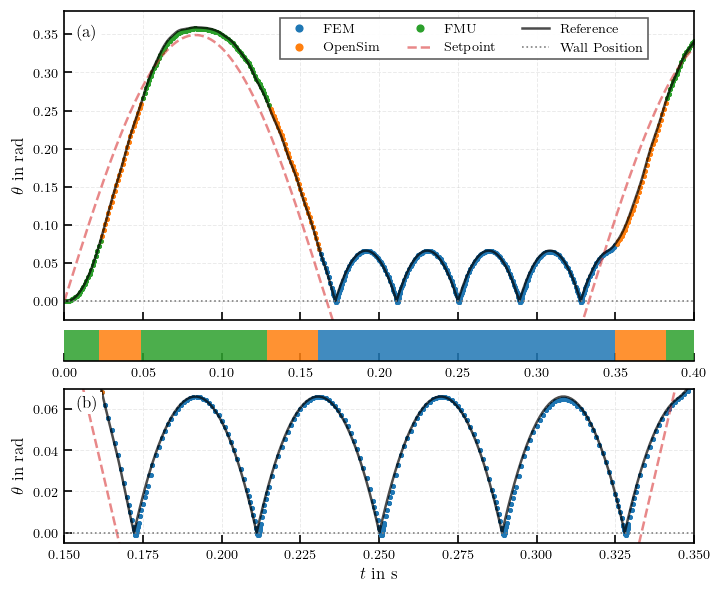

In [24]:
fig = plt.figure(figsize=(FULL_WIDTH, 0.82 * FULL_WIDTH), constrained_layout=True)
gs = fig.add_gridspec(3, 1, height_ratios=[4, 0.4, 2])
ax_full = fig.add_subplot(gs[0, 0])
ax_mode = fig.add_subplot(gs[1, 0], sharex=ax_full)
ax_contact = fig.add_subplot(gs[2, 0])

for ax in (ax_full, ax_contact):
    ax.plot(t_fem, theta_fem, label="FEM", **fem_style)
    ax.plot(t_opensim, theta_opensim, label="OpenSim", **opensim_style)
    ax.plot(t_fmu, theta_fmu, label="FMU", **fmu_style)
    ax.plot(setpoint_time, theta_ref, label="Setpoint", color=palette["setpoint"], linestyle="--", linewidth=1.5, alpha=0.55)
    ax.plot(ref_sol_reset['time'], ref_sol_reset['theta'], 'k-', label="Reference", markersize=1, linewidth=1.5, alpha=0.7)
    ax.axhline(0, color='gray', linestyle=':', linewidth=1, label="Wall Position")
    ax.grid(True, alpha=0.3)
    ax.set_ylabel(r"$\theta$ in $\mathrm{rad}$")

ax_full.set_ylim(-0.025, 0.38)
ax_full.tick_params(labelbottom=False)
ax_full.legend(loc="upper center", bbox_to_anchor=(0.635, 1), ncol=3, markerscale=2, fontsize=8)
ax_contact.set_xlabel(r"$t$ in $\mathrm{s}$")

ax_contact.set_xlim(0.15, 0.35)
ax_contact.set_ylim(-0.005, 0.07)

for t0_i, t1_i, mode in mode_intervals:
    ax_mode.broken_barh(
        [(t0_i, t1_i - t0_i)],
        (0, 1),
        facecolors=palette[mode.lower()],
        edgecolors="none",
        alpha=0.85,
    )

ax_mode.set_ylim(0, 1)
ax_mode.set_xlim(0, t_end)
ax_mode.set_yticks([])
ax_mode.grid(False)

for spine in ["left", "right", "top"]:
    ax_mode.spines[spine].set_visible(False)

for label, ax in [("(a)", ax_full), ("(b)", ax_contact)]:
    ax.text(0.02, 0.96,
        label, transform=ax.transAxes,
        ha="left", va="top",
        fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="none", alpha=1, pad=1.5),
    )
plt.show()

out = _repo / "thesis" / "figures" / "6_case_study" / "controlled_pendulum" / "validation"
out.mkdir(parents=True, exist_ok=True)
fig.savefig(out / "multi_model_switching.pdf")
fig.savefig(out / "multi_model_switching.png", dpi=300)
plt.show()


### Model Switching and Synchronicity

In [21]:
def scalar_value(value):
    if isinstance(value, dict):
        value = value.get("value", np.nan)
    if hasattr(value, "magnitude"):
        value = value.magnitude
    return float(value)


def get_state_value(state, name):
    if name in state:
        return scalar_value(state[name])
    if f"{name}_start" in state:
        return scalar_value(state[f"{name}_start"])
    return np.nan


switch_rows = []
for event in pendulum.sync_events:
    before = event["retrieved"]
    after = event["now"]

    row = {
        "t": event["time"],
        "from": event["from_mode"],
        "to": event["to_mode"],
    }

    for name in ["theta", "omega", "tau"]:
        before_value = get_state_value(before, name)
        after_value = get_state_value(after, name)
        row[f"delta_{name}"] = after_value - before_value
        row[f"abs_delta_{name}"] = abs(after_value - before_value)

    switch_rows.append(row)

df_switching = pd.DataFrame(switch_rows)

display(
    df_switching.style
    .format({
        "t": "{:.6f}",
        "delta_theta": "{:.3e}",
        "abs_delta_theta": "{:.3e}",
        "delta_omega": "{:.3e}",
        "abs_delta_omega": "{:.3e}",
        "delta_tau": "{:.3e}",
        "abs_delta_tau": "{:.3e}",
    })
    .hide(axis="index")
)


t,from,to,delta_theta,abs_delta_theta,delta_omega,abs_delta_omega,delta_tau,abs_delta_tau
0.022000,FMU,OpenSim,0.000e+00,0.000e+00,0.000e+00,0.000e+00,0.000e+00,0.000e+00
0.049000,OpenSim,FMU,0.000e+00,0.000e+00,0.000e+00,0.000e+00,0.000e+00,0.000e+00
0.129000,FMU,OpenSim,0.000e+00,0.000e+00,0.000e+00,0.000e+00,0.000e+00,0.000e+00
0.161000,OpenSim,FEM,-8.327e-17,8.327e-17,-1.243e-14,1.243e-14,1.776e-15,1.776e-15
0.350000,FEM,OpenSim,0.000e+00,0.000e+00,0.000e+00,0.000e+00,0.000e+00,0.000e+00
0.382000,OpenSim,FMU,0.000e+00,0.000e+00,0.000e+00,0.000e+00,0.000e+00,0.000e+00


In [22]:
switch_summary = {
    "n_switches": len(df_switching),
    "max_abs_delta_theta": df_switching["abs_delta_theta"].max(),
    "max_abs_delta_omega": df_switching["abs_delta_omega"].max(),
    "max_abs_delta_tau": df_switching["abs_delta_tau"].max(),
}

switch_summary


{'n_switches': 6,
 'max_abs_delta_theta': np.float64(8.326672684688674e-17),
 'max_abs_delta_omega': np.float64(1.2434497875801753e-14),
 'max_abs_delta_tau': np.float64(1.7763568394002505e-15)}

In [23]:
mode_colors = {
    "FMU": "#7C8DA6",
    "OpenSim": "#D58936",
    "FEM": "#4F8F6B",
}

setpoint_color = "#B23A48"
wall_color = "0.45"




